In [ ]:
!pip -q install \
"transformers>=4.51" \
"datasets>=4.8.4" \
"evaluate>=0.4.3" \
"accelerate>=1.10.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.7 MB/s eta 0:00:00


In [ ]:
!pip -q install \
"librosa>=0.10.2" \
"soundfile>=0.13.1"

In [ ]:
!pip -q install \
"pandas==2.2.2" \
"numpy>=1.26,<2.1" \
"matplotlib>=3.8.0" \
"seaborn>=0.13.2"

In [ ]:
!pip -q install \
"kagglehub>=0.3.12" \
"gradio>=5.0.0"

In [ ]:
import os
import glob
import random
import warnings
from dataclasses import dataclass
from typing import Any, Dict, List, Union, Optional

In [ ]:
import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import kagglehub

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from datasets import Dataset, DatasetDict, Audio

In [ ]:
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
SEED = 42

def set_all_seeds(seed):
    set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(SEED)

In [ ]:
dataset_path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print(f"Dataset downloaded to: {dataset_path}")

100%|██████████| 429M/429M [00:02<00:00, 151MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


In [ ]:
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

INTENSITY_MAP = {
    "01": "normal",
    "02": "strong",
}

STATEMENT_MAP = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door",
}

In [ ]:
all_wavs = glob.glob(
    os.path.join(dataset_path, "**", "*.wav"),
    recursive=True
)

print(f"Total wav files found: {len(all_wavs)}")

Total wav files found: 2880


In [ ]:
rows = []

for fp in all_wavs:
    fname = os.path.basename(fp)
    stem = os.path.splitext(fname)[0]
    parts = stem.split("-")

    if len(parts) != 7:
        continue

    _, _, emotion, intensity, statement, _, actor = parts

    rows.append({
        "path": fp,
        "filename": fname,
        "emotion_code": emotion,
        "emotion": EMOTION_MAP.get(emotion, "unknown"),
        "intensity_code": intensity,
        "intensity": INTENSITY_MAP.get(intensity, "unknown"),
        "statement_code": statement,
        "statement": STATEMENT_MAP.get(statement, "unknown"),
        "actor": int(actor),
    })

df = pd.DataFrame(rows)

print(f"Total usable rows: {len(df)}")
display(df.head())

Total usable rows: 2880


,path,filename,emotion_code,emotion,intensity_code,intensity,statement_code,statement,actor
0,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,03-01-06-02-01-02-12.wav,06,fearful,02,strong,01,Kids are talking by the door,12
1,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,03-01-07-01-02-02-12.wav,07,disgust,01,normal,02,Dogs are sitting by the door,12
2,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,03-01-07-02-01-01-12.wav,07,disgust,02,strong,01,Kids are talking by the door,12
3,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,03-01-03-02-02-01-12.wav,03,happy,02,strong,02,Dogs are sitting by the door,12
4,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,03-01-04-02-01-02-12.wav,04,sad,02,strong,01,Kids are talking by the door,12


In [ ]:
print("Emotion counts:")
print(df["emotion"].value_counts())

Emotion counts:
emotion
fearful      384
disgust      384
happy        384
sad          384
surprised    384
angry        384
calm         384
neutral      192
Name: count, dtype: int64


In [ ]:
print("Actors:")
print(sorted(df["actor"].unique()))
print(f"Number of actors: {df['actor'].nunique()}")

Actors:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Number of actors: 24


In [ ]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)

train_idx, temp_idx = next(
    gss1.split(df, groups=df["actor"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

In [ ]:
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)

val_idx, test_idx = next(
    gss2.split(temp_df, groups=temp_df["actor"])
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

In [ ]:
print(f"Train shape: {train_df.shape} | Actors: {sorted(train_df['actor'].unique())}")
print(f"Val shape  : {val_df.shape} | Actors: {sorted(val_df['actor'].unique())}")
print(f"Test shape : {test_df.shape} | Actors: {sorted(test_df['actor'].unique())}")

Train shape: (1920, 9) | Actors: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(13), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Val shape  : (480, 9) | Actors: [np.int64(9), np.int64(10), np.int64(12), np.int64(17)]
Test shape : (480, 9) | Actors: [np.int64(1), np.int64(2), np.int64(14), np.int64(19)]


In [ ]:
train_ds = Dataset.from_pandas(
    train_df[["path", "emotion"]].rename(columns={"path": "audio"})
)

val_ds = Dataset.from_pandas(
    val_df[["path", "emotion"]].rename(columns={"path": "audio"})
)

test_ds = Dataset.from_pandas(
    test_df[["path", "emotion"]].rename(columns={"path": "audio"})
)

In [ ]:
dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

In [ ]:
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

dataset

DatasetDict({
    train: Dataset({
        features: ['audio', 'emotion'],
        num_rows: 1920
    })
    validation: Dataset({
        features: ['audio', 'emotion'],
        num_rows: 480
    })
    test: Dataset({
        features: ['audio', 'emotion'],
        num_rows: 480
    })
})

In [ ]:
label_names = sorted(df["emotion"].unique())

label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

In [ ]:
print(f"label2id = {label2id}")
print(f"id2label = {id2label}")

label2id = {'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7}
id2label = {0: 'angry', 1: 'calm', 2: 'disgust', 3: 'fearful', 4: 'happy', 5: 'neutral', 6: 'sad', 7: 'surprised'}


In [ ]:
@dataclass
class DataCollatorAudioWithPadding:
    feature_extractor: Any
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    truncation: bool = False

    def __call__(self, features: List[Dict[str, Union[List[float], int]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": f["input_values"]} for f in features]

        batch = self.feature_extractor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            truncation=self.truncation,
            return_tensors="pt",
        )

        batch["labels"] = torch.tensor(
            [f["label"] for f in features],
            dtype=torch.long,
        )

        return batch

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(
        predictions=preds,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="macro"
    )

    return {
        "accuracy": acc["accuracy"],
        "macro_f1": f1["f1"],
    }

In [ ]:
model_names = [
    "base_wav2vec2_frozen",
    "finetuned_wav2vec2",
    "finetuned_hubert",
]

In [ ]:
MODEL_CONFIGS = {
    "base_wav2vec2_frozen": {
        "checkpoint": "facebook/wav2vec2-base",
        "freeze_encoder": True,
    },
    "finetuned_wav2vec2": {
        "checkpoint": "facebook/wav2vec2-base",
        "freeze_encoder": False,
    },
    "finetuned_hubert": {
        "checkpoint": "facebook/hubert-base-ls960",
        "freeze_encoder": False,
    },
}

In [ ]:
max_duration = 4.0

In [ ]:
def load_model(model_checkpoint, label2id, id2label, freeze_encoder=False):
    model = AutoModelForAudioClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
        ignore_mismatched_sizes=True,
    )

    if freeze_encoder:
        if hasattr(model, "wav2vec2"):
            for param in model.wav2vec2.parameters():
                param.requires_grad = False
        elif hasattr(model, "hubert"):
            for param in model.hubert.parameters():
                param.requires_grad = False

    return model

In [ ]:
def encode_dataset_for_model(dataset, feature_extractor, label2id, max_duration=4.0):
    def preprocess_function(batch):
        audio = batch["audio"]

        inputs = feature_extractor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            max_length=int(feature_extractor.sampling_rate * max_duration),
            truncation=True,
        )

        batch["input_values"] = inputs["input_values"][0]
        batch["label"] = label2id[batch["emotion"]]
        return batch

    encoded_dataset = dataset.map(preprocess_function)

    encoded_dataset = encoded_dataset.remove_columns(
        [
            col
            for col in encoded_dataset["train"].column_names
            if col not in ["input_values", "label"]
        ]
    )

    return encoded_dataset

In [ ]:
def train_and_evaluate_model(
    model_name,
    checkpoint,
    freeze_encoder=False,
    dataset=None,
    label2id=None,
    id2label=None,
    output_root="./emotion_model_outputs",
    learning_rate=1e-5,
    train_batch_size=8,
    eval_batch_size=8,
    num_train_epochs=8,
    warmup_ratio=0.1,
    max_duration=4.0
):
    print("\n" + "="*80)
    print(f"Training model: {model_name}")
    print(f"Checkpoint: {checkpoint}")
    print(f"Freeze encoder: {freeze_encoder}")
    print("="*80)

    # Load feature extractor
    feature_extractor = AutoFeatureExtractor.from_pretrained(checkpoint)

    # Encode dataset for this model
    encoded_dataset = encode_dataset_for_model(
        dataset=dataset,
        feature_extractor=feature_extractor,
        label2id=label2id,
        max_duration=max_duration
    )

    # Data collator
    data_collator = DataCollatorAudioWithPadding(feature_extractor=feature_extractor)

    # Load model
    model = load_model(
        model_checkpoint=checkpoint,
        label2id=label2id,
        id2label=id2label,
        freeze_encoder=freeze_encoder
    )

    # Output directory for this model
    model_output_dir = os.path.join(output_root, model_name)
    os.makedirs(model_output_dir, exist_ok=True)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=model_output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        num_train_epochs=num_train_epochs,
        warmup_ratio=warmup_ratio,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    # Trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    processing_class=feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)w

    # Train
    trainer.train()

    # Evaluate on test set
    test_metrics = trainer.evaluate(encoded_dataset["test"])
    print("\nTest metrics:", test_metrics)

    # Predict on test set
    pred_output = trainer.predict(encoded_dataset["test"])
    y_true = pred_output.label_ids
    y_pred = np.argmax(pred_output.predictions, axis=1)

    # Classification report
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=[id2label[i] for i in range(len(id2label))],
        output_dict=True
    )

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=[id2label[i] for i in range(len(id2label))]
    )

    print("\nClassification Report:")
    print(report_text)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Save model and feature extractor
    best_model_dir = os.path.join(model_output_dir, "best_model")
    trainer.save_model(best_model_dir)
    feature_extractor.save_pretrained(best_model_dir)

    print(f"\nSaved best model to: {best_model_dir}")

    return {
        "model_name": model_name,
        "checkpoint": checkpoint,
        "freeze_encoder": freeze_encoder,
        "trainer": trainer,
        "feature_extractor": feature_extractor,
        "encoded_dataset": encoded_dataset,
        "test_metrics": test_metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "classification_report_  dict": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm,
        "best_model_dir": best_model_dir
    }

In [ ]:
results = []

for model_name, cfg in MODEL_CONFIGS.items():
    result = train_and_evaluate_model(
        model_name=model_name,
        checkpoint=cfg["checkpoint"],
        freeze_encoder=cfg["freeze_encoder"],
        dataset=dataset,
        label2id=label2id,
        id2label=id2label,
        output_root="./emotion_model_outputs",
        learning_rate=1e-5,
        train_batch_size=8,
        eval_batch_size=8,
        num_train_epochs=8,
        warmup_ratio=0.1,
        max_duration=max_duration,
    )
    results.append(result)


Training model: base_wav2vec2_frozen
Checkpoint: facebook/wav2vec2-base
Freeze encoder: True


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1920 [00:00<?, ? examples/s]

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Test metrics: {'eval_loss': 1.2527353763580322, 'eval_accuracy': 0.5770833333333333, 'eval_macro_f1': 0.5465379957014527, 'eval_runtime': 18.4268, 'eval_samples_per_second': 26.049, 'eval_steps_per_second': 3.256, 'epoch': 8.0}

Classification Report:
              precision    recall  f1-score   support

       angry       0.71      0.84      0.77        64
        calm       0.56      1.00      0.72        64
     disgust       0.80      0.64      0.71        64
     fearful       0.92      0.53      0.67        64
       happy       0.40      0.56      0.46        64
     neutral       0.37      0.31      0.34        32
         sad       0.41      0.41      0.41        64
   surprised       0.60      0.19      0.29        64

    accuracy                           0.58       480
   macro avg       0.60      0.56      0.55       480
weighted avg       0.61      0.58      0.56       480



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved best model to: ./emotion_model_outputs/finetuned_hubert/best_model


In [ ]:
summary_rows = []

for r in results:
    summary_rows.append({
        "Model": r["model_name"],
        "Checkpoint": r["checkpoint"],
        "Frozen Encoder": r["freeze_encoder"],
        "Test Accuracy": r["test_metrics"].get("eval_accuracy"),
        "Test Macro-F1": r["test_metrics"].get("eval_macro_f1"),
        "Test Loss": r["test_metrics"].get("eval_loss"),
    })

comparison_df = pd.DataFrame(summary_rows)
comparison_df = comparison_df.sort_values(
    "Test Macro-F1",
    ascending=False
).reset_index(drop=True)

In [ ]:
print("Model Comparison Table")
display(comparison_df)

Model Comparison Table


,Model,Checkpoint,Frozen Encoder,Test Accuracy,Test Macro-F1,Test Loss
0,finetuned_wav2vec2,facebook/wav2vec2-base,False,0.720833,0.718487,1.017229
1,finetuned_hubert,facebook/hubert-base-ls960,False,0.577083,0.546538,1.252735
2,base_wav2vec2_frozen,facebook/wav2vec2-base,True,0.308333,0.229312,2.010960


In [ ]:
emotion_rows = []

for r in results:
    report = r["classification_report_dict"]

    for emotion in label_names:
        emotion_rows.append({
            "Model": r["model_name"],
            "Emotion": emotion,
            "Precision": report[emotion]["precision"],
            "Recall": report[emotion]["recall"],
            "F1": report[emotion]["f1-score"]
        })

emotion_df = pd.DataFrame(emotion_rows)

print("Per-class performance (long format):")
display(emotion_df.head(20))

Per-class performance (long format):


,Model,Emotion,Precision,Recall,F1
0,base_wav2vec2_frozen,angry,0.276923,0.843750,0.416988
1,base_wav2vec2_frozen,calm,0.346154,0.562500,0.428571
2,base_wav2vec2_frozen,disgust,0.076923,0.062500,0.068966
3,base_wav2vec2_frozen,fearful,0.521739,0.562500,0.541353
4,base_wav2vec2_frozen,happy,0.111111,0.031250,0.048780
5,base_wav2vec2_frozen,neutral,0.000000,0.000000,0.000000
6,base_wav2vec2_frozen,sad,1.000000,0.031250,0.060606
7,base_wav2vec2_frozen,surprised,0.350000,0.218750,0.269231
8,finetuned_wav2vec2,angry,1.000000,0.781250,0.877193
9,finetuned_wav2vec2,calm,0.738095,0.968750,0.837838


In [ ]:
emotion_f1_table = emotion_df.pivot(index="Emotion", columns="Model", values="F1")
print("Per-class F1 comparison:")
display(emotion_f1_table)

Per-class F1 comparison:


Model,base_wav2vec2_frozen,finetuned_hubert,finetuned_wav2vec2
Emotion,,,
angry,0.416988,0.771429,0.877193
calm,0.428571,0.719101,0.837838
disgust,0.068966,0.713043,0.822695
fearful,0.541353,0.673267,0.666667
happy,0.048780,0.464516,0.666667
neutral,0.000000,0.338983,0.689655
sad,0.060606,0.406250,0.514286
surprised,0.269231,0.285714,0.672897


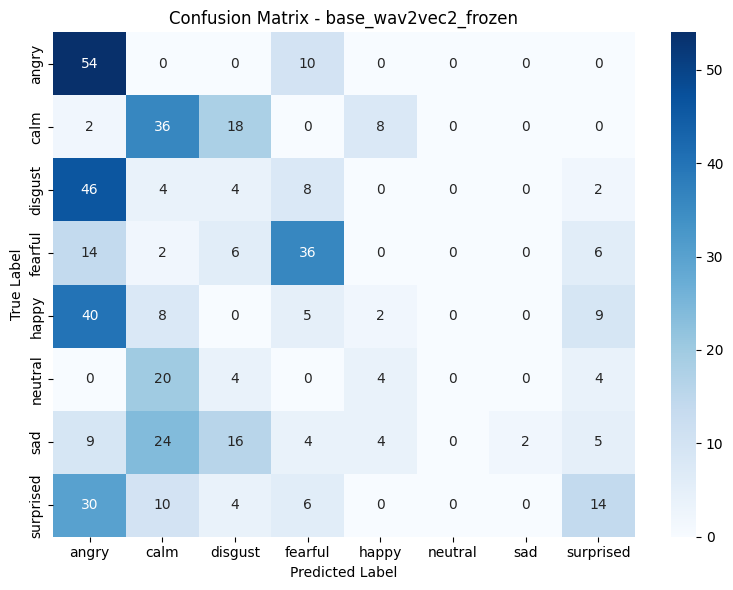

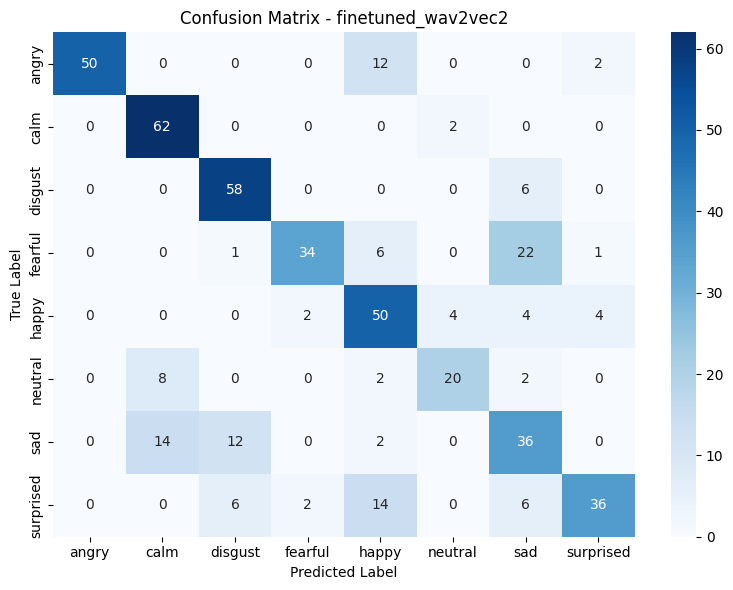

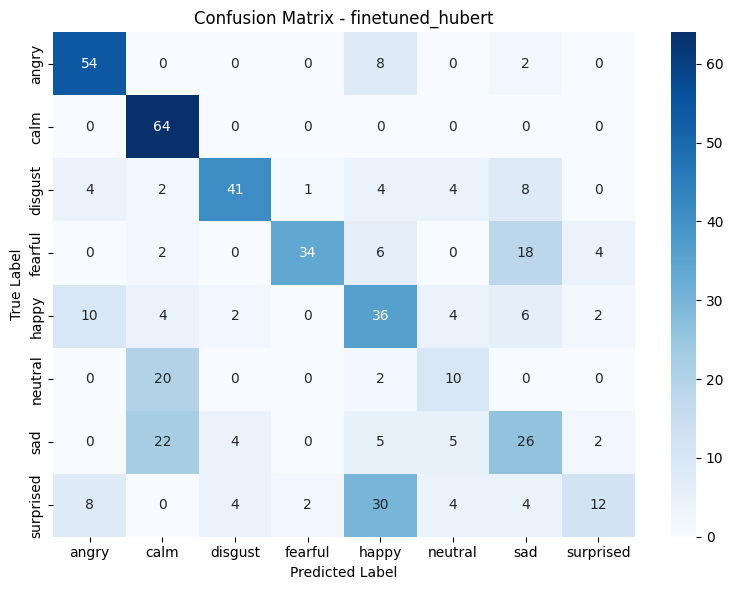

In [ ]:
for r in results:
    cm = r["confusion_matrix"]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[id2label[i] for i in range(len(id2label))],
        yticklabels=[id2label[i] for i in range(len(id2label))]
    )
    plt.title(f"Confusion Matrix - {r['model_name']}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [ ]:
best_result = sorted(
    results,
    key=lambda x: x["test_metrics"].get("eval_macro_f1", 0),
    reverse=True
)[0]

print("Best model based on Macro-F1:")
print("Model name:", best_result["model_name"])
print("Checkpoint:", best_result["checkpoint"])
print("Saved model path:", best_result["best_model_dir"])

Best model based on Macro-F1:
Model name: finetuned_wav2vec2
Checkpoint: facebook/wav2vec2-base
Saved model path: ./emotion_model_outputs/finetuned_wav2vec2/best_model


In [ ]:
best_model_dir = best_result["best_model_dir"]

infer_feature_extractor = AutoFeatureExtractor.from_pretrained(best_model_dir)
infer_model = AutoModelForAudioClassification.from_pretrained(best_model_dir).to(device)
infer_model.eval()

print("Loaded best model from:", best_model_dir)

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Loaded best model from: ./emotion_model_outputs/finetuned_wav2vec2/best_model


In [ ]:
def predict_emotion(audio_path, model, feature_extractor, max_duration=4.0):
    # Load audio at 16kHz
    audio, sr = librosa.load(audio_path, sr=16000)

    # Convert to model input
    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        max_length=int(feature_extractor.sampling_rate * max_duration),
        truncation=True,
        return_tensors="pt"
    )

    # Move tensors to device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Disable gradient calculation for inference
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))
    pred_label = model.config.id2label[pred_id]

    # Create sorted probability dictionary
    scores = {
        model.config.id2label[i]: float(probs[i])
        for i in range(len(probs))
    }
    scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

    return pred_label, scores

In [ ]:
sample_path = test_df.iloc[0]["path"]

pred_label, scores = predict_emotion(
    audio_path=sample_path,
    model=infer_model,
    feature_extractor=infer_feature_extractor,
    max_duration=max_duration
)

print("Sample file:", sample_path)
print("Predicted emotion:", pred_label)
print("Confidence scores:")
for emotion, score in scores.items():
    print(f"{emotion:12s}: {score:.4f}")

Sample file: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_01/03-01-06-01-02-02-01.wav
Predicted emotion: sad
Confidence scores:
sad         : 0.8592
calm        : 0.0345
neutral     : 0.0281
happy       : 0.0182
angry       : 0.0159
fearful     : 0.0158
surprised   : 0.0151
disgust     : 0.0133


In [ ]:
best_y_true = best_result["y_true"]
best_y_pred = best_result["y_pred"]

# Rebuild the test paths in the same order as dataset["test"]
test_paths = test_df["path"].tolist()

misclassified = []

for i, (yt, yp) in enumerate(zip(best_y_true, best_y_pred)):
    if yt != yp:
        misclassified.append({
            "path": test_paths[i],
            "true_label": id2label[int(yt)],
            "pred_label": id2label[int(yp)]
        })

misclassified_df = pd.DataFrame(misclassified)

print("Number of misclassified examples:", len(misclassified_df))
display(misclassified_df.head(10))

Number of misclassified examples: 134


,path,true_label,pred_label
0,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,fearful,sad
1,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,surprised,happy
2,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,surprised,happy
3,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,disgust,sad
4,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,surprised,happy
5,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,angry,happy
6,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,angry,happy
7,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,angry,happy
8,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,angry,happy
9,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...,surprised,happy


In [ ]:
os.makedirs("./report_tables", exist_ok=True)

comparison_df.to_csv("./report_tables/model_comparison.csv", index=False)
emotion_df.to_csv("./report_tables/per_class_metrics_long.csv", index=False)
emotion_f1_table.to_csv("./report_tables/per_class_f1_comparison.csv")

print("Saved tables to ./report_tables/")

Saved tables to ./report_tables/


In [ ]:
import gradio as gr

def gradio_predict(audio_filepath):
    if audio_filepath is None:
        return "No audio received.", pd.DataFrame(columns=["emotion", "confidence"])

    pred_label, scores = predict_emotion(
        audio_path=audio_filepath,
        model=infer_model,
        feature_extractor=infer_feature_extractor,
        max_duration=max_duration
    )

    score_df = pd.DataFrame({
        "emotion": list(scores.keys()),
        "confidence": list(scores.values())
    })

    return f"Detected emotion: {pred_label}", score_df

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Audio(sources=["microphone", "upload"], type="filepath", label="Speak or upload audio"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Dataframe(label="Confidence scores")
    ],
    title="Speech Emotion Recognition Demo",
    description="Upload or record speech audio to predict emotion using the best fine-tuned model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36e68b1272059295ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
